<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/11_2_qat_pb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -q tensorflow
! pip install -q tensorflow-model-optimization

In [2]:
import tempfile
import os

import tensorflow as tf

from tensorflow_model_optimization.python.core.keras.compat import keras

In [3]:
import numpy as np
import tensorflow as tf

try:
    import tf_keras as keras
except ImportError:
    from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)


In [4]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Match paper setup: use 50k training samples
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
Train: (50000, 28, 28) (50000,)
Test : (10000, 28, 28) (10000,)


In [5]:
def build_float_ann():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(10)   # logits
    ])
    return model

float_model = build_float_ann()
float_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
float_model = build_float_ann()

float_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train model
float_history = float_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    verbose=1
)

float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)

print(f"FLOAT Test accuracy: {float_test_acc:.4f} | loss: {float_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 19s 11ms/step - loss: 0.4341 - accuracy: 0.8877
Epoch 2/40
1563/1563 [==============================] - 14s 9ms/step - loss: 0.2134 - accuracy: 0.9388
Epoch 3/40
1563/1563 [==============================] - 7s 5ms/step - loss: 0.1588 - accuracy: 0.9537
Epoch 4/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1251 - accuracy: 0.9635
Epoch 5/40
1563/1563 [==============================] - 7s 5ms/step - loss: 0.1012 - accuracy: 0.9713
Epoch 6/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0837 - accuracy: 0.9763
Epoch 7/40
1563/1563 [==============================] - 7s 5ms/step - loss: 0.0694 - accuracy: 0.9810
Epoch 8/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0586 - accuracy: 0.9846
Epoch 9/40
1563/1563 [==============================] - 8s 5ms/step - loss: 0.0497 - accuracy: 0.9867
Epoch 10/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.

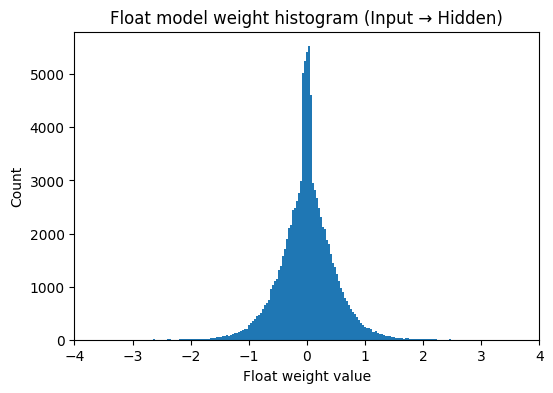

In [7]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-4, 4])   # optional, for visual comparison
plt.show()

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt

# all_w = []

# for layer in float_model.layers:
#     if hasattr(layer, "get_weights") and len(layer.get_weights()) > 0:
#         w = layer.get_weights()[0]
#         if len(w.shape) == 2:
#             all_w.append(w.reshape(-1))

# all_w = np.concatenate(all_w)

# plt.figure(figsize=(8, 5))
# plt.hist(all_w, bins=200)
# plt.xlabel("Synaptic weight value")
# plt.ylabel("Count")
# plt.title("Synaptic Weight Distribution")
# plt.grid(True, alpha=0.3)
# plt.show()

In [9]:
import tensorflow_model_optimization as tfmot

LEVELS = tf.constant([-1.0, -0.75, -0.25, 0.0, 0.25, 0.75, 1.0], dtype=tf.float32)

def nearest_level(x, levels=LEVELS):
    x = tf.convert_to_tensor(x)
    levels = tf.cast(levels, x.dtype)
    x_exp = tf.expand_dims(x, axis=-1)
    d = tf.abs(x_exp - levels)
    idx = tf.argmin(d, axis=-1)
    return tf.gather(levels, idx)

def quantize_scaled_to_levels(w, levels=LEVELS, eps=1e-8):
    levels = tf.cast(levels, w.dtype)

    @tf.custom_gradient
    def _q(x):
        mx = tf.reduce_max(tf.abs(x)) + eps
        s = 1.0 / mx
        x_s = x * s
        x_qs = nearest_level(x_s, levels)
        x_q = x_qs / s

        def grad(dy):
            return dy                         # STE

        return x_q, grad

    return _q(w)

class DiscreteLevelsQuantizer(tfmot.quantization.keras.quantizers.Quantizer):
    def __init__(self, levels):
        super().__init__()
        self.levels = tf.constant(levels, dtype=tf.float32)

    def build(self, tensor_shape, name, layer):
        return {}

    def __call__(self, inputs, training, weights, **kwargs):
        return quantize_scaled_to_levels(inputs, self.levels)

    def get_config(self):
        return {"levels": self.levels.numpy().tolist()}

In [10]:
class DenseAllQuantizedConfig(tfmot.quantization.keras.QuantizeConfig):

    def __init__(self, levels):
        self.levels = levels
        self.wq = DiscreteLevelsQuantizer(levels)
        self.aq = tfmot.quantization.keras.quantizers.MovingAverageQuantizer(
            num_bits=8,
            per_axis=False,
            symmetric=False,
            narrow_range=False
        )

    def get_weights_and_quantizers(self, layer):

        return [(layer.kernel, self.wq)]

    def get_activations_and_quantizers(self, layer):
        return [(layer.activation, self.aq)]

    def set_quantize_weights(self, layer, quantize_weights):
        layer.kernel = quantize_weights[0]

    def set_quantize_activations(self, layer, quantize_activations):
        layer.activation = quantize_activations[0]

    def get_output_quantizers(self, layer):
        return []

    def get_config(self):
        return {"levels": list(map(float, self.levels))}


In [11]:
dense_qconfig = DenseAllQuantizedConfig(levels=LEVELS.numpy().tolist())

def annotate_dense(layer):
    if isinstance(layer, keras.layers.Dense):
        return tfmot.quantization.keras.quantize_annotate_layer(
            layer, quantize_config=dense_qconfig
        )
    return layer

custom_objs = {
    "DenseAllQuantizedConfig": DenseAllQuantizedConfig,
    "DiscreteLevelsQuantizer": DiscreteLevelsQuantizer,
}

with tfmot.quantization.keras.quantize_scope(custom_objs):
    with keras.utils.custom_object_scope(custom_objs):

        annotated_model = keras.models.clone_model(float_model, clone_function=annotate_dense)
        annotated_model.set_weights(float_model.get_weights())

        qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)

qat_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quant_flatten_1 (QuantizeW  (None, 784)               1         
 rapperV2)                                                       
                                                                 
 quant_dense_2 (QuantizeWra  (None, 128)               100483    
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 10)                1293      
 pperV2)                                                         
                                                                 
Total params: 101777 (397.57 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 7 (28.00 Byte)
_________________________________________________________________


In [12]:
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # smaller LR for fine-tuning
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

qat_history = qat_model.fit(
    x_train, y_train,
    epochs=40,
)

qat_test_loss, qat_test_acc = qat_model.evaluate(x_test, y_test, verbose=0)
print(f"QAT Test accuracy: {qat_test_acc:.4f} | loss: {qat_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 18s 11ms/step - loss: 0.0930 - accuracy: 0.9714
Epoch 2/40
1563/1563 [==============================] - 18s 11ms/step - loss: 0.0365 - accuracy: 0.9865
Epoch 3/40
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0257 - accuracy: 0.9908
Epoch 4/40
1563/1563 [==============================] - 18s 11ms/step - loss: 0.0196 - accuracy: 0.9935
Epoch 5/40
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0161 - accuracy: 0.9945
Epoch 6/40
1563/1563 [==============================] - 18s 12ms/step - loss: 0.0130 - accuracy: 0.9957
Epoch 7/40
1563/1563 [==============================] - 18s 11ms/step - loss: 0.0124 - accuracy: 0.9961
Epoch 8/40
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0108 - accuracy: 0.9969
Epoch 9/40
1563/1563 [==============================] - 18s 12ms/step - loss: 0.0099 - accuracy: 0.9969
Epoch 10/40
1563/1563 [==============================] - 19s 12m

In [13]:
import numpy as np

LEVELS_NP = np.array([-1.0, -0.75, -0.25, 0.0, 0.25, 0.75, 1.0], dtype=np.float32)

def hard_snap_fixed_levels(kernel, levels=LEVELS_NP):
    idx = np.argmin(np.abs(kernel[..., None] - levels), axis=-1)
    return levels[idx]

for layer in qat_model.layers:
    inner = getattr(layer, "layer", None)

    if inner is None:
        continue
    if not isinstance(inner, keras.layers.Dense):
        continue

    weights = inner.get_weights()
    if len(weights) == 0:
        continue

    weights[0] = hard_snap_fixed_levels(weights[0])
    inner.set_weights(weights)

    print(f"{inner.name} unique values:",
          np.unique(np.round(inner.get_weights()[0], 6)))

dense_2 unique values: [-0.75 -0.25  0.    0.25  0.75]
dense_3 unique values: [-0.25  0.  ]


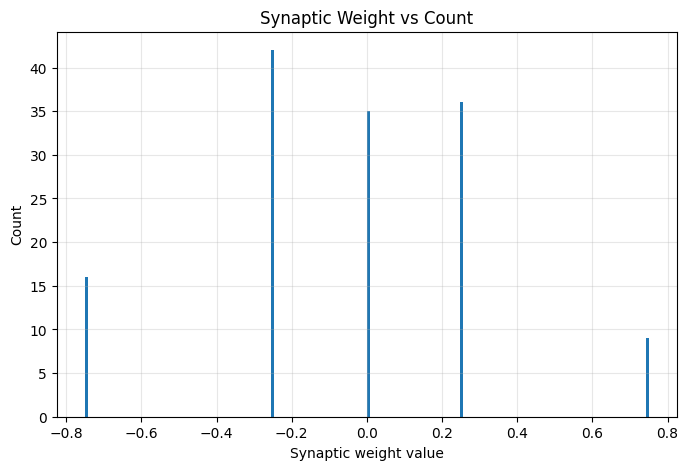

Unique weight values:
[-0.75 -0.25  0.    0.25  0.75]


In [14]:
# Plot synaptic weight value vs count for all Dense layers

import numpy as np
import matplotlib.pyplot as plt

all_weights = []

for layer in qat_model.layers:
    inner = getattr(layer, "layer", None)

    if inner is None:
        continue
    if not isinstance(inner, keras.layers.Dense):
        continue

    w = inner.get_weights()[0]
    all_weights.append(w.reshape(-1))

all_weights = np.concatenate(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights, bins=200)
plt.xlabel("Synaptic weight value")
plt.ylabel("Count")
plt.title("Synaptic Weight vs Count")
plt.grid(True, alpha=0.3)
plt.show()

print("Unique weight values:")
print(np.unique(np.round(all_weights, 6)))

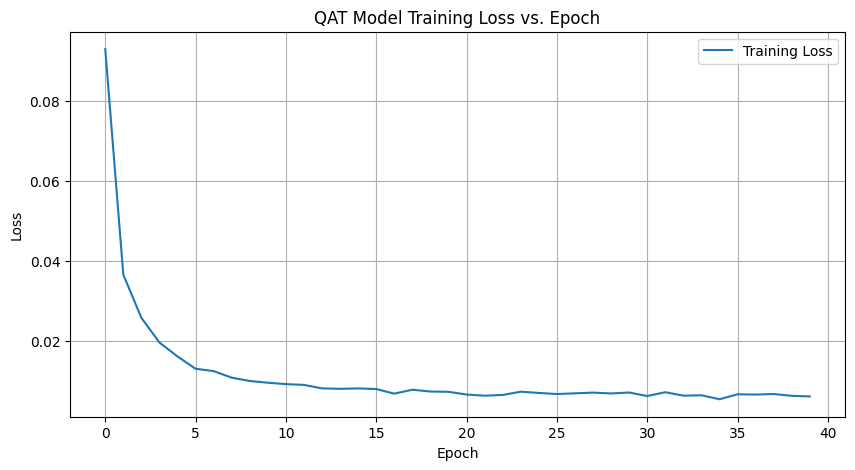

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(qat_history.history['loss'], label='Training Loss')
plt.title('QAT Model Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

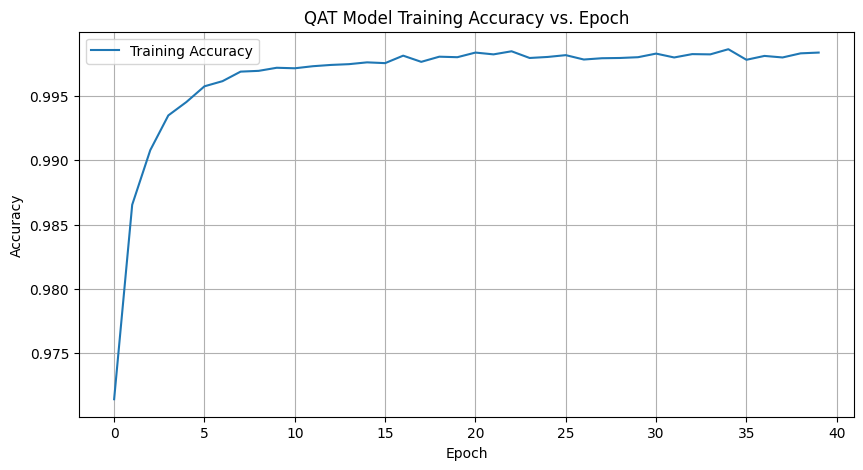

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(qat_history.history['accuracy'], label='Training Accuracy')
plt.title('QAT Model Training Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()